# Delayed-Feedback Game Learning Experiments

Public code for the paper "Optimal Learning in Two-Player Zero-Sum Games under Delayed Feedback" in AISTATS2026 (under review).

This notebook reproduces the core experiments on two-player zero-sum games with delayed feedback, comparing the proposed method (`ProposedPlayer`) against the baseline (`FujimotoPlayer`).
It evaluates both social regret and individual regret under various delays $D$, learning rates $\eta$, and random seeds used for generating the payoff matrices.

---

## Environment Setup

This notebook uses `uv` for environment and dependency management.

### Setup Instructions

1. Install `uv` (see https://docs.astral.sh/uv/getting-started/installation/)
2. Run `uv sync` to install dependencies
3. When running the notebook, select the Python interpreter from `.venv` as the kernel

---

## References

Yuma Fujimoto, Abe Kenshi, and Kaito Ariu. Learning from delayed feedback in games via extra prediction. *In Advances in Neural Information Processing Systems*, volume 29, 2025. URL https://arxiv.org/abs/2509.22426.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


class OptimisticHedge:
    def __init__(self, m, eta, is_max_player=True):
        self.m = m
        self.eta = eta
        self.is_max_player = is_max_player
        self.cumulative_vectors = np.zeros(m)

    def choose_action(self, optimistic_prediction):
        exponent = self.eta * (optimistic_prediction + self.cumulative_vectors)
        if not self.is_max_player:
            exponent *= -1
        weights = np.exp(exponent - np.max(exponent))
        return weights / np.sum(weights)

    def update(self, vector):
        self.cumulative_vectors += vector


class FujimotoPlayer:
    def __init__(self, m, D, L, is_max_player=True):
        self.m = m
        self.D = D
        self.L = L
        self.eta = 1.0 / (np.sqrt(2) * (D + 1) * (D + 2) * L)
        self.is_max_player = is_max_player
        self.cumulative_vectors = np.zeros(m)

    def choose_action(self, t, history):
        if t == 1:
            strategy = np.zeros(self.m)
            strategy[0] = 1.0
            return strategy
        if t <= self.D + 1:
            return np.full(self.m, 1.0 / self.m)

        optimistic_prediction = (self.D + 1) * history[t - self.D - 2]
        exponent = self.eta * (optimistic_prediction + self.cumulative_vectors)

        if not self.is_max_player:
            exponent *= -1

        weights = np.exp(exponent - np.max(exponent))
        return weights / np.sum(weights)

    def update(self, vector):
        self.cumulative_vectors += vector


class ProposedPlayer:
    def __init__(self, m, D, eta=0.25, is_max_player=True):
        self.m = m
        self.D = D
        self.eta = eta
        self.is_max_player = is_max_player
        self.learners = [OptimisticHedge(m, eta, is_max_player) for _ in range(D + 1)]

    def choose_action(self, t, history):
        if t == 1:
            strategy = np.zeros(self.m)
            strategy[0] = 1.0
            return strategy
        if t <= self.D + 1:
            return np.full(self.m, 1.0 / self.m)

        d = (t - 1) % (self.D + 1)
        optimistic_prediction = history[t - self.D - 2]
        return self.learners[d].choose_action(optimistic_prediction)

    def update(self, t, vector):
        if t > self.D:
            d_feedback = (t - self.D - 1) % (self.D + 1)
            self.learners[d_feedback].update(vector)


def run_simulation(player_x, player_y, A, T, D):
    m_x, m_y = A.shape
    x_hist = np.zeros((T, m_x))
    y_hist = np.zeros((T, m_y))
    g_hist = np.zeros((T, m_x))
    l_hist = np.zeros((T, m_y))

    for t in range(1, T + 1):
        x_t = player_x.choose_action(t, g_hist)
        y_t = player_y.choose_action(t, l_hist)
        x_hist[t - 1], y_hist[t - 1] = x_t, y_t

        g_t = A @ y_t
        l_t = A.T @ x_t
        g_hist[t - 1], l_hist[t - 1] = g_t, l_t

        if t > D:
            feedback_g = g_hist[t - D - 1]
            feedback_l = l_hist[t - D - 1]
            if isinstance(player_x, ProposedPlayer):
                player_x.update(t, feedback_g)
            else:
                player_x.update(feedback_g)
            if isinstance(player_y, ProposedPlayer):
                player_y.update(t, feedback_l)
            else:
                player_y.update(feedback_l)

    best_fixed_x_payoffs = np.zeros(m_x)
    best_fixed_y_losses = np.zeros(m_y)
    actual_x_payoff = 0.0
    actual_y_loss = 0.0

    for t in range(T):
        g_t, l_t = g_hist[t], l_hist[t]
        x_t, y_t = x_hist[t], y_hist[t]
        best_fixed_x_payoffs += g_t
        best_fixed_y_losses += l_t
        actual_x_payoff += np.dot(x_t, g_t)
        actual_y_loss += np.dot(y_t, l_t)

    regret_x = np.max(best_fixed_x_payoffs) - actual_x_payoff
    regret_y = actual_y_loss - np.min(best_fixed_y_losses)
    return regret_x, regret_y


T_normalized = 200_000
D_VALUES_normalized = list(range(0, 201, 40))
SEED_LIST = [1, 2, 3, 4, 5, 6, 7, 8]
PROPOSED_ETA_VALUES_normalized = [0.025, 0.05, 0.1, 0.25]

results_normalized = {}

total_experiments = (
    len(SEED_LIST)
    * len(D_VALUES_normalized)
    * (len(PROPOSED_ETA_VALUES_normalized) + 1)
)

with tqdm(total=total_experiments, desc="Overall Progress", unit="exp") as pbar:
    for seed in SEED_LIST:
        np.random.seed(seed)
        A_raw = np.random.uniform(-1, 1, size=(2, 2))

        max_abs_value = np.max(np.abs(A_raw))
        if max_abs_value > 0:
            A = A_raw / max_abs_value
        else:
            A = A_raw

        L = np.max(np.abs(A))

        matrix_name = f"Normalized Random Matrix (seed={seed})"
        results_normalized[matrix_name] = {
            "matrix": A,
            "L": L,
            "Proposed": {
                eta: {"regret_x": [], "regret_y": []}
                for eta in PROPOSED_ETA_VALUES_normalized
            },
            "Fujimoto": {"regret_x": [], "regret_y": []},
        }

        pbar.write(
            f"\n[{matrix_name}] L∞ = {L:.4f}, Original max |value|: {max_abs_value:.4f}"
        )

        for D in D_VALUES_normalized:
            for eta in PROPOSED_ETA_VALUES_normalized:
                player_x_proposed = ProposedPlayer(
                    m=2, D=D, eta=eta, is_max_player=True
                )
                player_y_proposed = ProposedPlayer(
                    m=2, D=D, eta=eta, is_max_player=False
                )
                regret_x, regret_y = run_simulation(
                    player_x_proposed, player_y_proposed, A, T_normalized, D
                )
                results_normalized[matrix_name]["Proposed"][eta]["regret_x"].append(
                    regret_x
                )
                results_normalized[matrix_name]["Proposed"][eta]["regret_y"].append(
                    regret_y
                )
                pbar.update(1)

            player_x_fujimoto = FujimotoPlayer(
                m=2, D=D, L=L, is_max_player=True
            )
            player_y_fujimoto = FujimotoPlayer(
                m=2, D=D, L=L, is_max_player=False
            )
            regret_x, regret_y = run_simulation(
                player_x_fujimoto, player_y_fujimoto, A, T_normalized, D
            )
            results_normalized[matrix_name]["Fujimoto"]["regret_x"].append(regret_x)
            results_normalized[matrix_name]["Fujimoto"]["regret_y"].append(regret_y)
            pbar.update(1)

            if D == D_VALUES_normalized[0]:
                pbar.write(f"  Fujimoto η = {player_x_fujimoto.eta:.6f}")

print("\nExperiments completed!")

num_seeds_norm = len(SEED_LIST)
num_D_values_norm = len(D_VALUES_normalized)

fujimoto_regret_x_norm = np.zeros((num_seeds_norm, num_D_values_norm))
fujimoto_regret_y_norm = np.zeros((num_seeds_norm, num_D_values_norm))
proposed_regret_x_norm = {
    eta: np.zeros((num_seeds_norm, num_D_values_norm))
    for eta in PROPOSED_ETA_VALUES_normalized
}
proposed_regret_y_norm = {
    eta: np.zeros((num_seeds_norm, num_D_values_norm))
    for eta in PROPOSED_ETA_VALUES_normalized
}

for seed_idx, (matrix_name, data) in enumerate(results_normalized.items()):
    fujimoto_regret_x_norm[seed_idx, :] = np.array(data["Fujimoto"]["regret_x"])
    fujimoto_regret_y_norm[seed_idx, :] = np.array(data["Fujimoto"]["regret_y"])
    for eta in PROPOSED_ETA_VALUES_normalized:
        proposed_regret_x_norm[eta][seed_idx, :] = np.array(
            data["Proposed"][eta]["regret_x"]
        )
        proposed_regret_y_norm[eta][seed_idx, :] = np.array(
            data["Proposed"][eta]["regret_y"]
        )

fujimoto_data_norm = fujimoto_regret_x_norm + fujimoto_regret_y_norm
proposed_data_norm = {
    eta: proposed_regret_x_norm[eta] + proposed_regret_y_norm[eta]
    for eta in PROPOSED_ETA_VALUES_normalized
}

fujimoto_mean_norm = np.mean(fujimoto_data_norm, axis=0)
fujimoto_std_norm = np.std(fujimoto_data_norm, axis=0)

proposed_mean_norm = {
    eta: np.mean(proposed_data_norm[eta], axis=0)
    for eta in PROPOSED_ETA_VALUES_normalized
}
proposed_std_norm = {
    eta: np.std(proposed_data_norm[eta], axis=0)
    for eta in PROPOSED_ETA_VALUES_normalized
}

Overall Progress:   0%|          | 0/240 [00:00<?, ?exp/s]


[Normalized Random Matrix (seed=1)] L∞ = 1.0000, Original max |value|: 0.9998
  Fujimoto η = 0.353553

[Normalized Random Matrix (seed=2)] L∞ = 1.0000, Original max |value|: 0.9481
  Fujimoto η = 0.353553

[Normalized Random Matrix (seed=3)] L∞ = 1.0000, Original max |value|: 0.4182
  Fujimoto η = 0.353553

[Normalized Random Matrix (seed=4)] L∞ = 1.0000, Original max |value|: 0.9454
  Fujimoto η = 0.353553

[Normalized Random Matrix (seed=5)] L∞ = 1.0000, Original max |value|: 0.8372
  Fujimoto η = 0.353553

[Normalized Random Matrix (seed=6)] L∞ = 1.0000, Original max |value|: 0.9166
  Fujimoto η = 0.353553

[Normalized Random Matrix (seed=7)] L∞ = 1.0000, Original max |value|: 0.8474
  Fujimoto η = 0.353553

[Normalized Random Matrix (seed=8)] L∞ = 1.0000, Original max |value|: 0.9371
  Fujimoto η = 0.353553

Experiments completed!


/var/folders/m_/ypc7t4ns3lb1clc__t0hq6w40000gn/T/ipykernel_77558/3398891622.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  eta_cmap_individual = plt.cm.get_cmap("tab10", len(PROPOSED_ETA_VALUES_normalized))


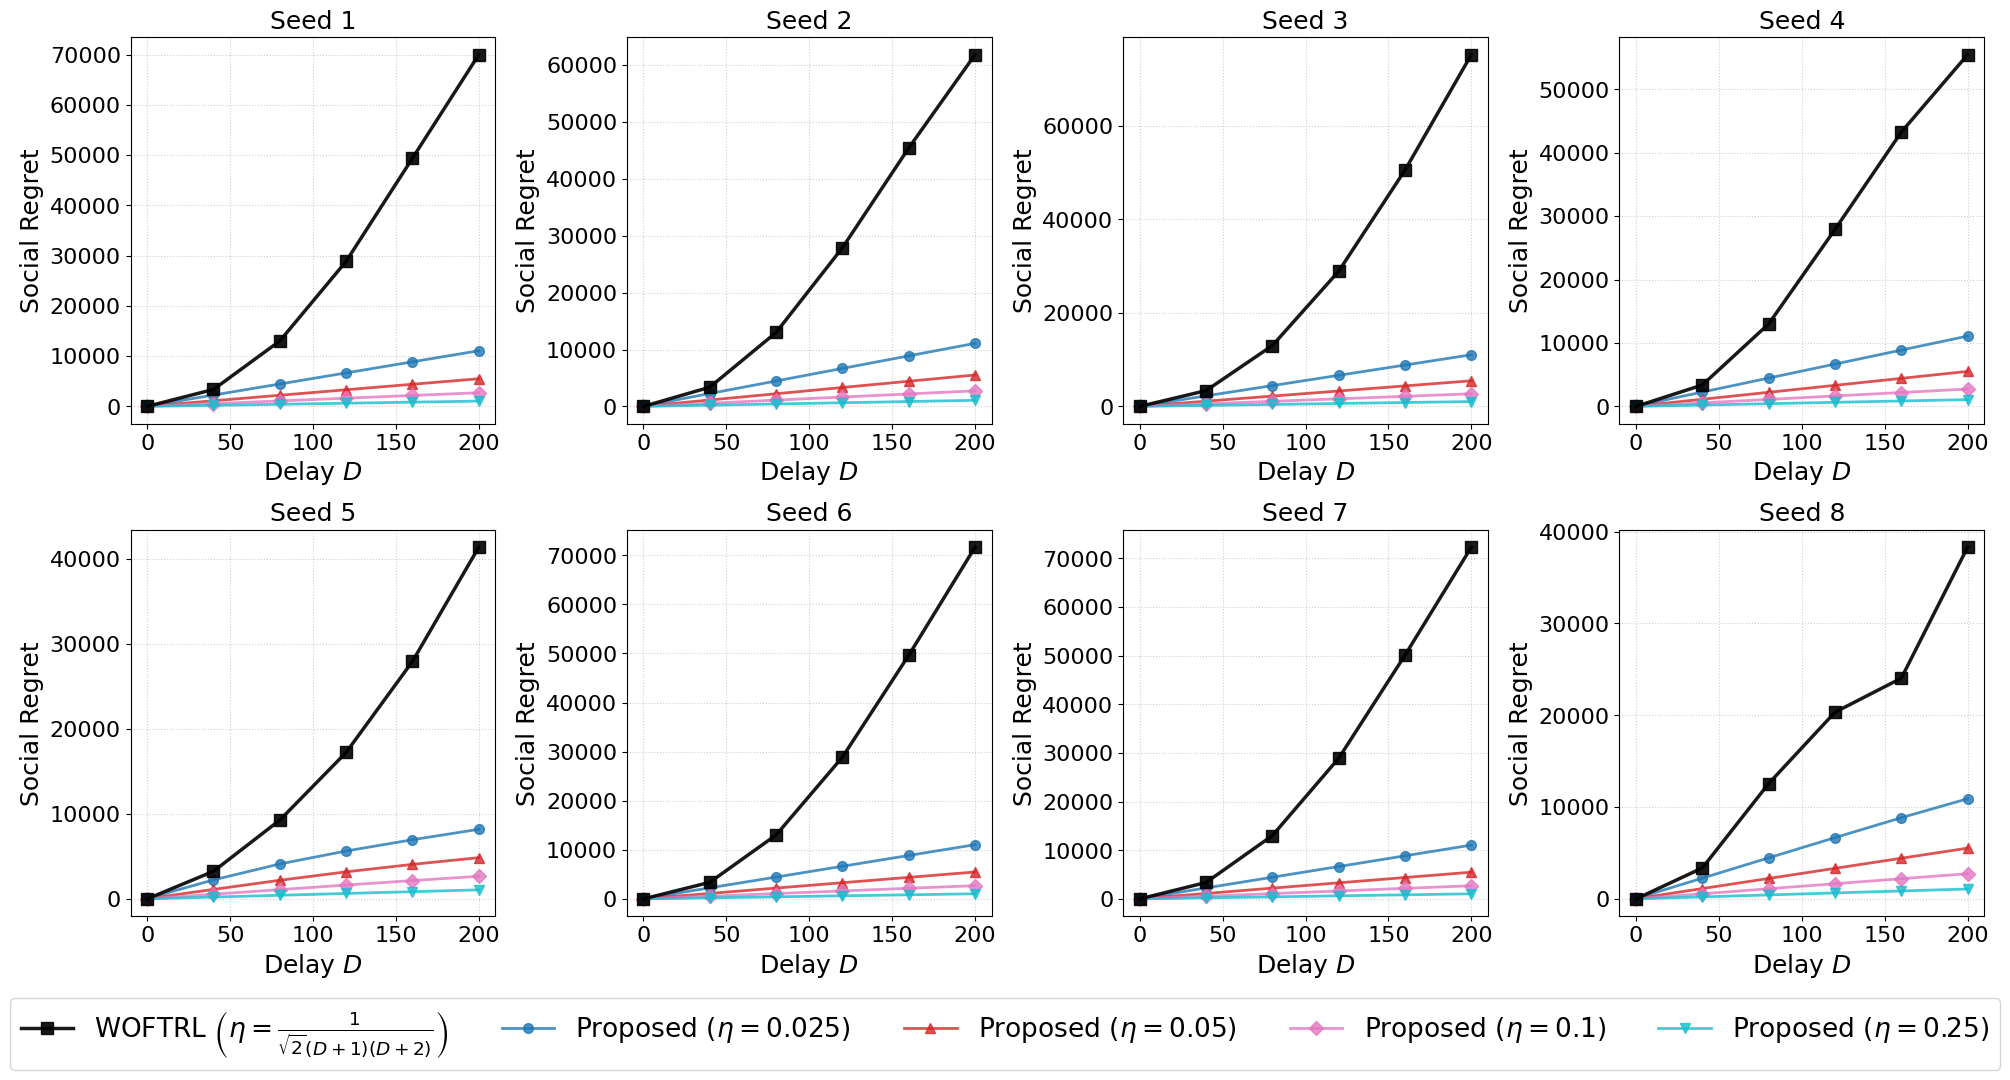

In [2]:
num_seeds_plot = len(SEED_LIST)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

eta_cmap_individual = plt.cm.get_cmap("tab10", len(PROPOSED_ETA_VALUES_normalized))
eta_colors_individual = {
    eta: eta_cmap_individual(i) for i, eta in enumerate(PROPOSED_ETA_VALUES_normalized)
}
proposed_markers_individual = {
    eta: marker
    for eta, marker in zip(PROPOSED_ETA_VALUES_normalized, ["o", "^", "D", "v"])
}

for idx, (matrix_name, data) in enumerate(results_normalized.items()):
    ax = axes[idx]

    fujimoto_social_regret = np.array(data["Fujimoto"]["regret_x"]) + np.array(
        data["Fujimoto"]["regret_y"]
    )

    ax.plot(
        D_VALUES_normalized,
        fujimoto_social_regret,
        "s-",
        linewidth=2.5,
        markersize=8,
        label=r"WOFTRL $\left(\eta = \frac{1}{\sqrt{2} (D+1)(D+2)}\right)$",
        color="black",
        alpha=0.9,
        zorder=10,
    )

    for eta in PROPOSED_ETA_VALUES_normalized:
        color = eta_colors_individual[eta]
        marker = proposed_markers_individual[eta]
        regrets = np.array(data["Proposed"][eta]["regret_x"]) + np.array(
            data["Proposed"][eta]["regret_y"]
        )

        ax.plot(
            D_VALUES_normalized,
            regrets,
            "-",
            linewidth=2,
            marker=marker,
            markersize=7,
            label=f"Proposed ($\\eta={eta}$)",
            color=color,
            alpha=0.8,
        )

    ax.set_xlabel("Delay $D$", fontsize=18)
    ax.set_ylabel("Social Regret", fontsize=18)
    ax.set_title(f"Seed {SEED_LIST[idx]}", fontsize=18)
    ax.tick_params(axis="both", which="major", labelsize=16)
    ax.grid(True, linestyle=":", alpha=0.6)

for idx in range(num_seeds_plot, len(axes)):
    axes[idx].axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=len(handles),
    fontsize=19,
    frameon=True,
)

plt.tight_layout()
plt.show()

/var/folders/m_/ypc7t4ns3lb1clc__t0hq6w40000gn/T/ipykernel_77558/2356047067.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  eta_cmap_individual = plt.cm.get_cmap("tab10", len(PROPOSED_ETA_VALUES_normalized))


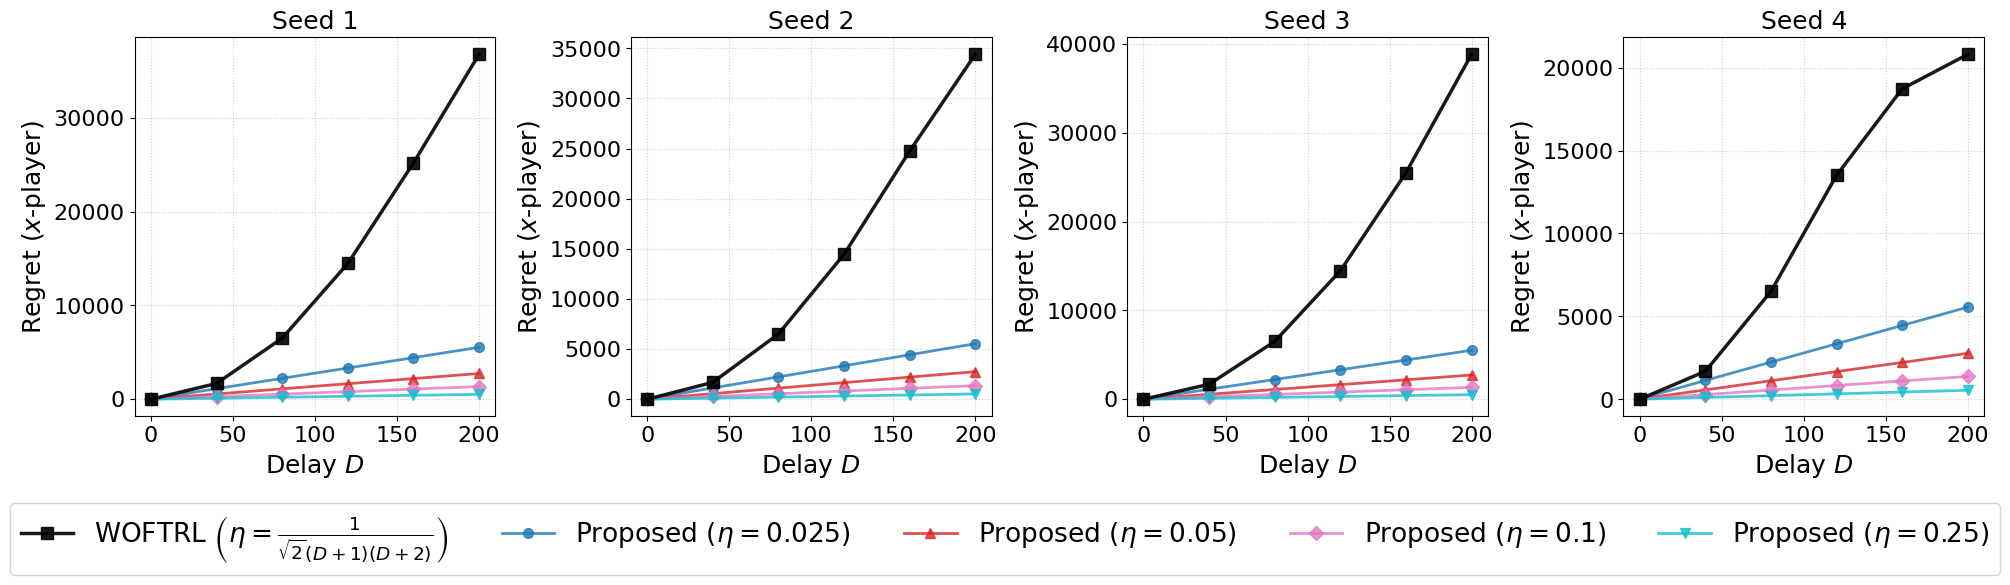

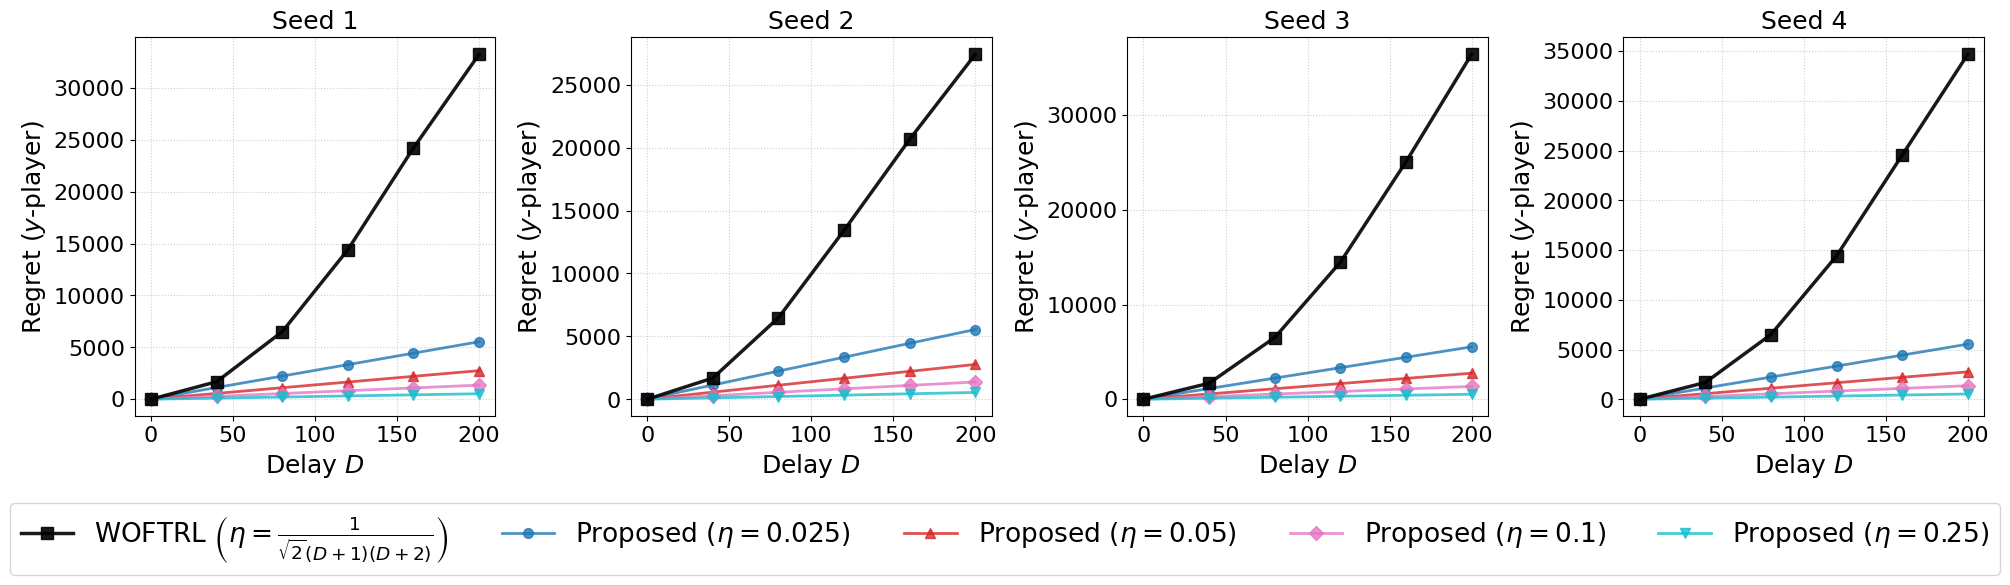

In [3]:
SEED_LIST_SHORT = [1, 2, 3, 4]
num_seeds_plot = len(SEED_LIST_SHORT)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

eta_cmap_individual = plt.cm.get_cmap("tab10", len(PROPOSED_ETA_VALUES_normalized))
eta_colors_individual = {
    eta: eta_cmap_individual(i) for i, eta in enumerate(PROPOSED_ETA_VALUES_normalized)
}
proposed_markers_individual = {
    eta: marker
    for eta, marker in zip(PROPOSED_ETA_VALUES_normalized, ["o", "^", "D", "v"])
}

for idx, (matrix_name, data) in enumerate(results_normalized.items()):
    if idx >= 4:
        break
    ax = axes[idx]

    fujimoto_regret_x = np.array(data["Fujimoto"]["regret_x"])

    ax.plot(
        D_VALUES_normalized,
        fujimoto_regret_x,
        "s-",
        linewidth=2.5,
        markersize=8,
        label=r"WOFTRL $\left(\eta = \frac{1}{\sqrt{2} (D+1)(D+2)}\right)$",
        color="black",
        alpha=0.9,
        zorder=10,
    )

    for eta in PROPOSED_ETA_VALUES_normalized:
        color = eta_colors_individual[eta]
        marker = proposed_markers_individual[eta]
        regrets_x = np.array(data["Proposed"][eta]["regret_x"])

        ax.plot(
            D_VALUES_normalized,
            regrets_x,
            "-",
            linewidth=2,
            marker=marker,
            markersize=7,
            label=f"Proposed ($\\eta={eta}$)",
            color=color,
            alpha=0.8,
        )

    ax.set_xlabel("Delay $D$", fontsize=18)
    ax.set_ylabel("Regret ($x$-player)", fontsize=18)
    ax.set_title(f"Seed {SEED_LIST_SHORT[idx]}", fontsize=18)
    ax.tick_params(axis="both", which="major", labelsize=16)
    ax.grid(True, linestyle=":", alpha=0.6)

for idx in range(num_seeds_plot, len(axes)):
    axes[idx].axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=len(handles),
    fontsize=19,
    frameon=True,
)

plt.tight_layout()
plt.show()

num_seeds_plot = len(SEED_LIST_SHORT)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()

for idx, (matrix_name, data) in enumerate(results_normalized.items()):
    if idx >= 4:
        break
    ax = axes[idx]

    fujimoto_regret_y = np.array(data["Fujimoto"]["regret_y"])

    ax.plot(
        D_VALUES_normalized,
        fujimoto_regret_y,
        "s-",
        linewidth=2.5,
        markersize=8,
        label=r"WOFTRL $\left(\eta = \frac{1}{\sqrt{2} (D+1)(D+2)}\right)$",
        color="black",
        alpha=0.9,
        zorder=10,
    )

    for eta in PROPOSED_ETA_VALUES_normalized:
        color = eta_colors_individual[eta]
        marker = proposed_markers_individual[eta]
        regrets_y = np.array(data["Proposed"][eta]["regret_y"])

        ax.plot(
            D_VALUES_normalized,
            regrets_y,
            "-",
            linewidth=2,
            marker=marker,
            markersize=7,
            label=f"Proposed ($\\eta={eta}$)",
            color=color,
            alpha=0.8,
        )

    ax.set_xlabel("Delay $D$", fontsize=18)
    ax.set_ylabel("Regret ($y$-player)", fontsize=18)
    ax.set_title(f"Seed {SEED_LIST_SHORT[idx]}", fontsize=18)
    ax.tick_params(axis="both", which="major", labelsize=16)
    ax.grid(True, linestyle=":", alpha=0.6)

for idx in range(num_seeds_plot, len(axes)):
    axes[idx].axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=len(handles),
    fontsize=19,
    frameon=True,
)

plt.tight_layout()
plt.show()

In [4]:
def run_simulation_with_history(player_x, player_y, A, T, D):
    m_x, m_y = A.shape
    x_hist = np.zeros((T, m_x))
    y_hist = np.zeros((T, m_y))
    g_hist = np.zeros((T, m_x))
    l_hist = np.zeros((T, m_y))

    for t in range(1, T + 1):
        x_t = player_x.choose_action(t, g_hist)
        y_t = player_y.choose_action(t, l_hist)
        x_hist[t - 1], y_hist[t - 1] = x_t, y_t

        g_t = A @ y_t
        l_t = A.T @ x_t
        g_hist[t - 1], l_hist[t - 1] = g_t, l_t

        if t > D:
            feedback_g = g_hist[t - D - 1]
            feedback_l = l_hist[t - D - 1]
            player_x.update(t, feedback_g)
            player_y.update(t, feedback_l)

    regret_x_history = []
    regret_y_history = []
    best_fixed_x_payoffs = np.zeros(m_x)
    best_fixed_y_losses = np.zeros(m_y)
    actual_x_payoff = 0.0
    actual_y_loss = 0.0

    for t in range(T):
        g_t, l_t = g_hist[t], l_hist[t]
        x_t, y_t = x_hist[t], y_hist[t]
        best_fixed_x_payoffs += g_t
        best_fixed_y_losses += l_t
        actual_x_payoff += np.dot(x_t, g_t)
        actual_y_loss += np.dot(y_t, l_t)

        regret_x = np.max(best_fixed_x_payoffs) - actual_x_payoff
        regret_y = actual_y_loss - np.min(best_fixed_y_losses)
        regret_x_history.append(regret_x)
        regret_y_history.append(regret_y)

    return np.array(regret_x_history), np.array(regret_y_history)


T_analysis = 50_000
D_VALUES_ANALYSIS = [5, 10, 15, 20]
SEED_LIST_SHORT = [1, 2, 3, 4]
ETA_VALUES_ANALYSIS = [0.025, 0.05, 0.1, 0.25]

results_time_series = {}

total_experiments = (
    len(SEED_LIST_SHORT) * len(D_VALUES_ANALYSIS) * len(ETA_VALUES_ANALYSIS)
)

with tqdm(
    total=total_experiments, desc="Time series analysis progress", unit="exp"
) as pbar:
    for seed in SEED_LIST_SHORT:
        np.random.seed(seed)
        A_raw = np.random.uniform(-1, 1, size=(2, 2))
        max_abs_value = np.max(np.abs(A_raw))
        if max_abs_value > 0:
            A = A_raw / max_abs_value
        else:
            A = A_raw

        matrix_name = f"Matrix_seed{seed}"
        results_time_series[matrix_name] = {
            "matrix": A,
            "seed": seed,
            "D_eta_results": {},
        }

        pbar.write(f"\n[{matrix_name}]")

        for D in D_VALUES_ANALYSIS:
            results_time_series[matrix_name]["D_eta_results"][D] = {}

            for eta in ETA_VALUES_ANALYSIS:
                player_x = ProposedPlayer(m=2, D=D, eta=eta, is_max_player=True)
                player_y = ProposedPlayer(m=2, D=D, eta=eta, is_max_player=False)

                regret_x_history, regret_y_history = run_simulation_with_history(
                    player_x, player_y, A, T_analysis, D
                )
                results_time_series[matrix_name]["D_eta_results"][D][eta] = {
                    "regret_x": regret_x_history,
                    "regret_y": regret_y_history,
                }

                pbar.update(1)

print("\nExperiments completed!")

Time series analysis progress:   0%|          | 0/64 [00:00<?, ?exp/s]


[Matrix_seed1]

[Matrix_seed2]

[Matrix_seed3]

[Matrix_seed4]

Experiments completed!


/var/folders/m_/ypc7t4ns3lb1clc__t0hq6w40000gn/T/ipykernel_77558/1759049984.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  eta_cmap_ts = plt.cm.get_cmap("tab10", len(ETA_VALUES_ANALYSIS))


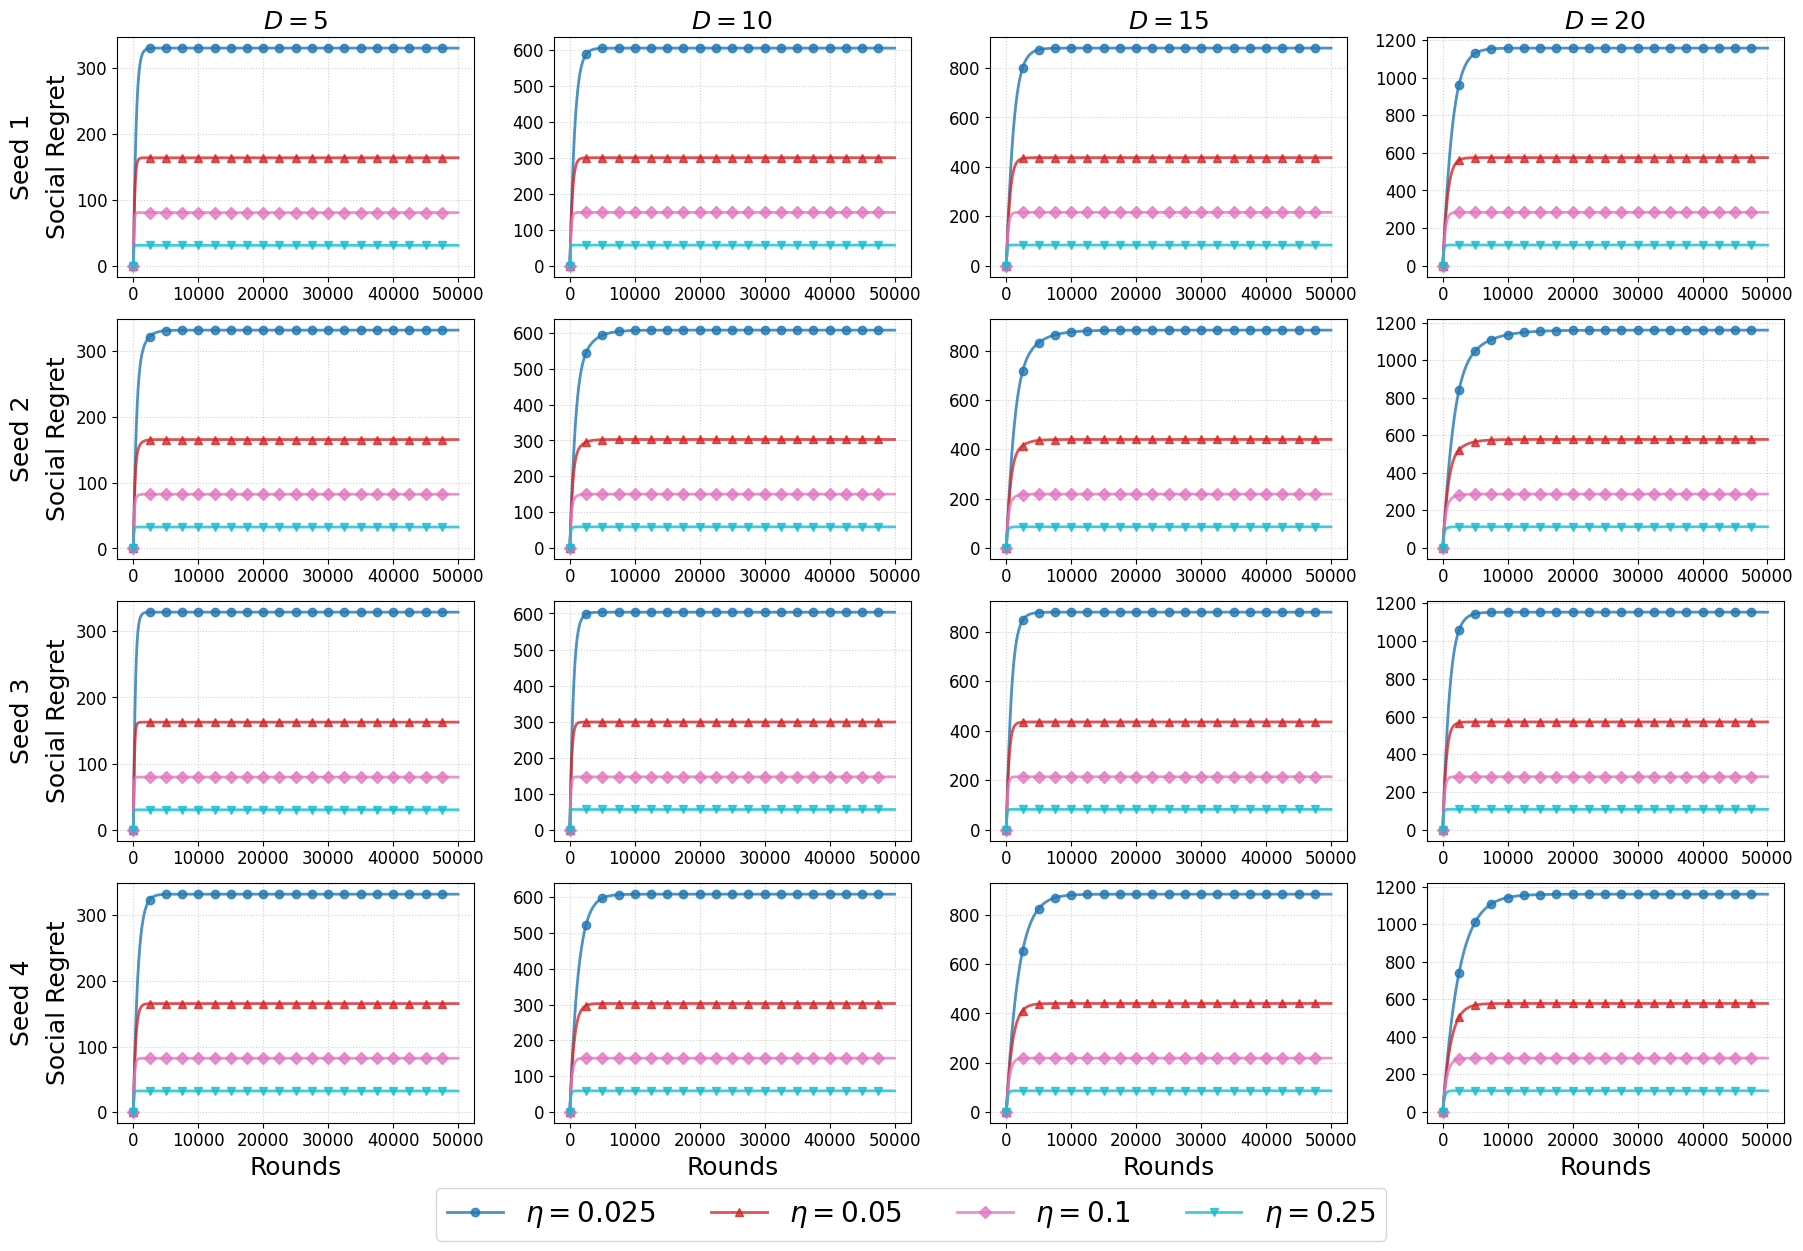

In [5]:
SEED_LIST_SHORT = [1, 2, 3, 4]
USE_LOG_SCALE = False

eta_cmap_ts = plt.cm.get_cmap("tab10", len(ETA_VALUES_ANALYSIS))
eta_colors_ts = {eta: eta_cmap_ts(i) for i, eta in enumerate(ETA_VALUES_ANALYSIS)}
eta_markers_ts = {
    eta: marker for eta, marker in zip(ETA_VALUES_ANALYSIS, ["o", "^", "D", "v"])
}
markevery_ts = max(T_analysis // 20, 1)

fig, axes = plt.subplots(len(SEED_LIST_SHORT), len(D_VALUES_ANALYSIS), figsize=(18, 12))

for seed_idx, (matrix_name, data) in enumerate(results_time_series.items()):
    for d_idx, D in enumerate(D_VALUES_ANALYSIS):
        ax = axes[seed_idx, d_idx]

        for eta in ETA_VALUES_ANALYSIS:
            regret_x_history = data["D_eta_results"][D][eta]["regret_x"]
            regret_y_history = data["D_eta_results"][D][eta]["regret_y"]
            regret_history = regret_x_history + regret_y_history

            time_steps = np.arange(1, T_analysis + 1)
            ax.plot(
                time_steps,
                regret_history,
                linewidth=2,
                marker=eta_markers_ts[eta],
                markevery=markevery_ts,
                markersize=6,
                label=f"$\eta={eta}$",
                color=eta_colors_ts[eta],
                alpha=0.8,
            )

        if USE_LOG_SCALE:
            ax.set_xscale("log")

        ax.grid(True, linestyle=":", alpha=0.6)
        ax.tick_params(axis="both", which="major", labelsize=12)

        if seed_idx == len(SEED_LIST_SHORT) - 1:
            ax.set_xlabel(f"Rounds", fontsize=18)
        if d_idx == 0:
            ax.set_ylabel("Social Regret", fontsize=18)

        if seed_idx == 0:
            ax.set_title(f"$D={D}$", fontsize=18)
        if d_idx == 0:
            ax.text(
                -0.3,
                0.5,
                f'Seed {data["seed"]}',
                transform=ax.transAxes,
                fontsize=18,
                va="center",
                rotation=90,
            )

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    fontsize=20,
    loc="lower center",
    ncol=len(ETA_VALUES_ANALYSIS),
    bbox_to_anchor=(0.5, -0.05),
)

scale_info = " (log scale)" if USE_LOG_SCALE else " (linear scale)"
plt.tight_layout()
plt.show()

/var/folders/m_/ypc7t4ns3lb1clc__t0hq6w40000gn/T/ipykernel_77558/3310012531.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  eta_cmap_ts = plt.cm.get_cmap("tab10", len(ETA_VALUES_ANALYSIS))


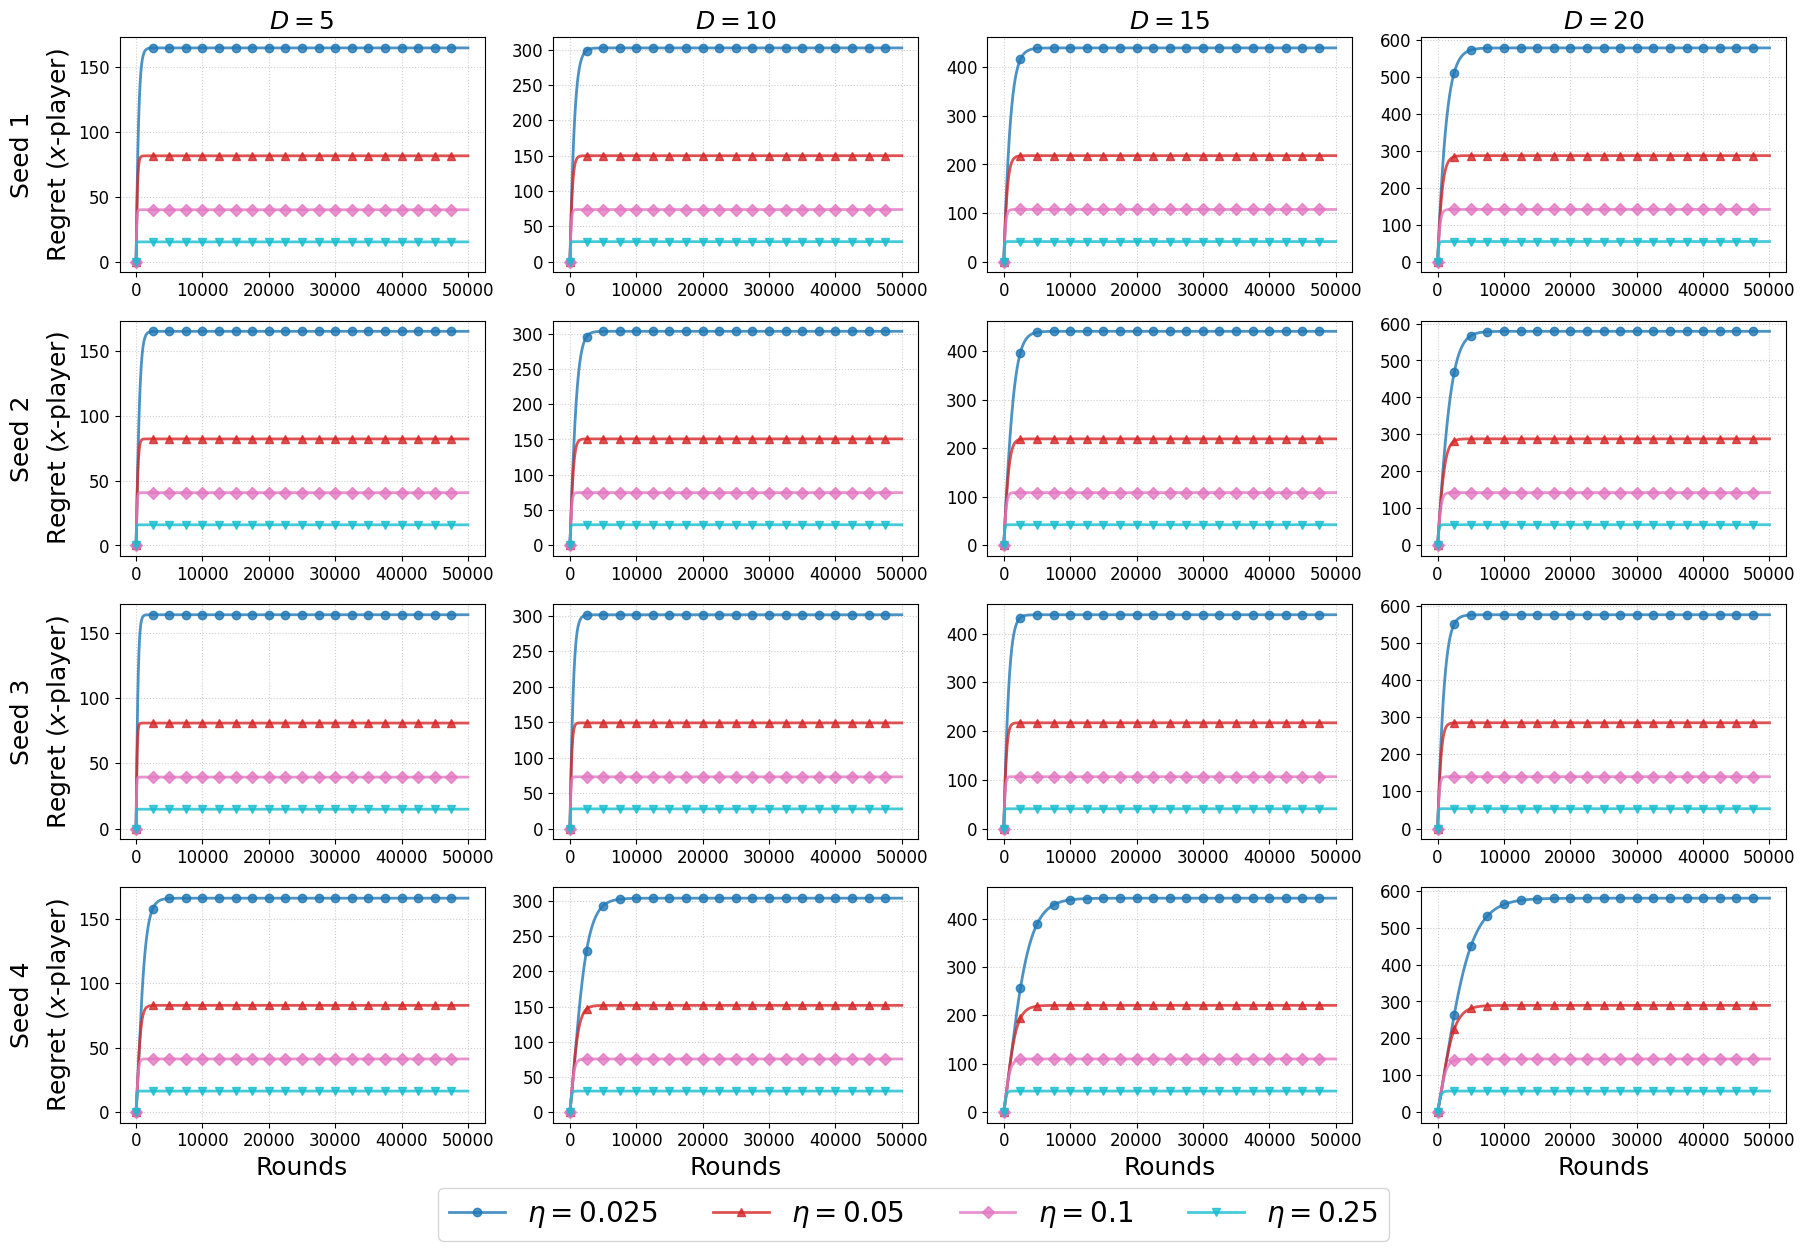

In [6]:
SEED_LIST_SHORT = [1, 2, 3, 4]
USE_LOG_SCALE = False

eta_cmap_ts = plt.cm.get_cmap("tab10", len(ETA_VALUES_ANALYSIS))
eta_colors_ts = {eta: eta_cmap_ts(i) for i, eta in enumerate(ETA_VALUES_ANALYSIS)}
eta_markers_ts = {
    eta: marker for eta, marker in zip(ETA_VALUES_ANALYSIS, ["o", "^", "D", "v"])
}
markevery_ts = max(T_analysis // 20, 1)

fig, axes = plt.subplots(len(SEED_LIST_SHORT), len(D_VALUES_ANALYSIS), figsize=(18, 12))

for seed_idx, (matrix_name, data) in enumerate(results_time_series.items()):
    for d_idx, D in enumerate(D_VALUES_ANALYSIS):
        ax = axes[seed_idx, d_idx]

        for eta in ETA_VALUES_ANALYSIS:
            regret_x_history = data["D_eta_results"][D][eta]["regret_x"]

            time_steps = np.arange(1, T_analysis + 1)
            ax.plot(
                time_steps,
                regret_x_history,
                linewidth=2,
                marker=eta_markers_ts[eta],
                markevery=markevery_ts,
                markersize=6,
                label=f"$\eta={eta}$",
                color=eta_colors_ts[eta],
                alpha=0.8,
            )

        if USE_LOG_SCALE:
            ax.set_xscale("log")

        ax.grid(True, linestyle=":", alpha=0.6)
        ax.tick_params(axis="both", which="major", labelsize=12)

        if seed_idx == len(SEED_LIST_SHORT) - 1:
            ax.set_xlabel(f"Rounds", fontsize=18)
        if d_idx == 0:
            ax.set_ylabel("Regret ($x$-player)", fontsize=18)

        if seed_idx == 0:
            ax.set_title(f"$D={D}$", fontsize=18)
        if d_idx == 0:
            ax.text(
                -0.3,
                0.5,
                f'Seed {data["seed"]}',
                transform=ax.transAxes,
                fontsize=18,
                va="center",
                rotation=90,
            )

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    fontsize=20,
    loc="lower center",
    ncol=len(ETA_VALUES_ANALYSIS),
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout()
plt.show()

/var/folders/m_/ypc7t4ns3lb1clc__t0hq6w40000gn/T/ipykernel_77558/4206460751.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  eta_cmap_ts = plt.cm.get_cmap("tab10", len(ETA_VALUES_ANALYSIS))


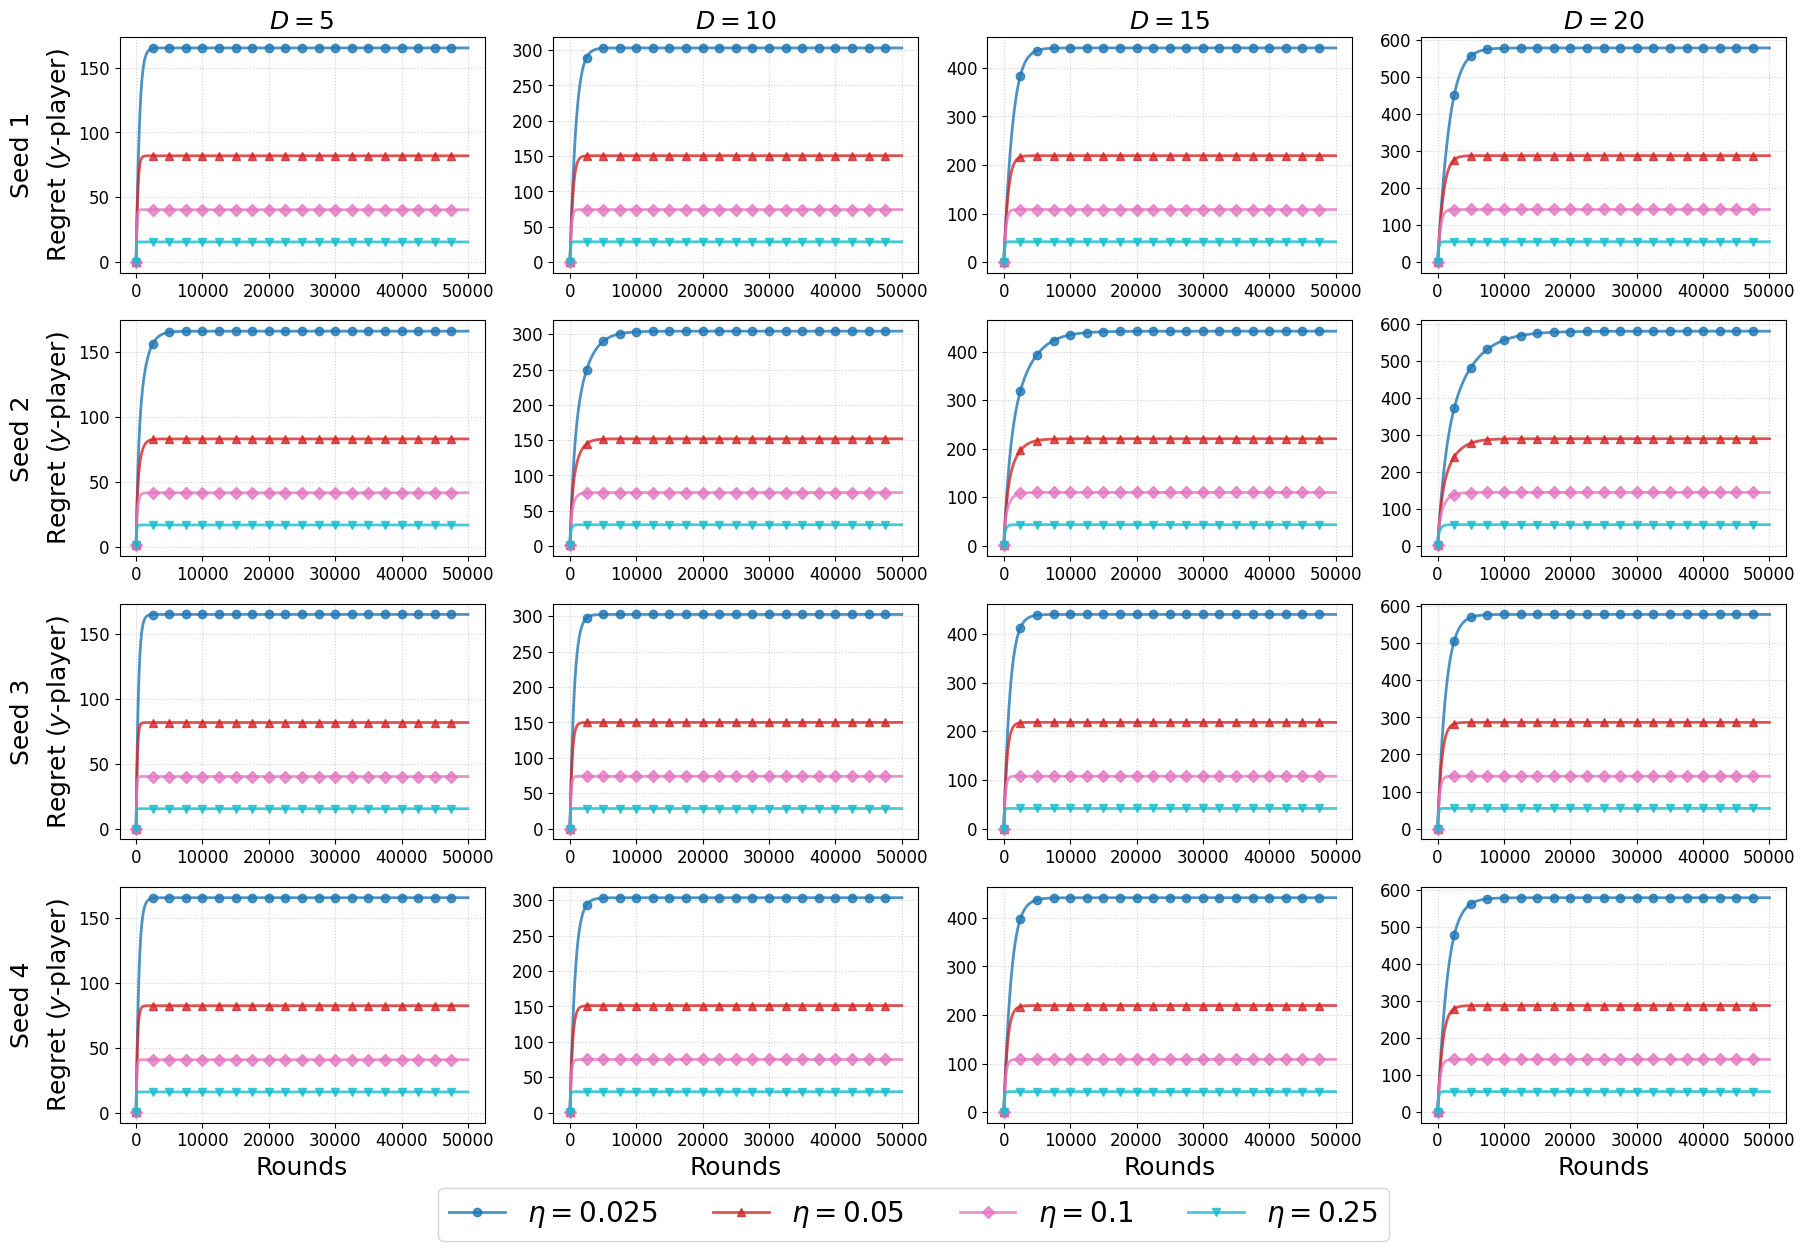

In [7]:
SEED_LIST_SHORT = [1, 2, 3, 4]
USE_LOG_SCALE = False

eta_cmap_ts = plt.cm.get_cmap("tab10", len(ETA_VALUES_ANALYSIS))
eta_colors_ts = {eta: eta_cmap_ts(i) for i, eta in enumerate(ETA_VALUES_ANALYSIS)}
eta_markers_ts = {
    eta: marker for eta, marker in zip(ETA_VALUES_ANALYSIS, ["o", "^", "D", "v"])
}
markevery_ts = max(T_analysis // 20, 1)

fig, axes = plt.subplots(len(SEED_LIST_SHORT), len(D_VALUES_ANALYSIS), figsize=(18, 12))

for seed_idx, (matrix_name, data) in enumerate(results_time_series.items()):
    for d_idx, D in enumerate(D_VALUES_ANALYSIS):
        ax = axes[seed_idx, d_idx]

        for eta in ETA_VALUES_ANALYSIS:
            regret_y_history = data["D_eta_results"][D][eta]["regret_y"]

            time_steps = np.arange(1, T_analysis + 1)
            ax.plot(
                time_steps,
                regret_y_history,
                linewidth=2,
                marker=eta_markers_ts[eta],
                markevery=markevery_ts,
                markersize=6,
                label=f"$\eta={eta}$",
                color=eta_colors_ts[eta],
                alpha=0.8,
            )

        if USE_LOG_SCALE:
            ax.set_xscale("log")

        ax.grid(True, linestyle=":", alpha=0.6)
        ax.tick_params(axis="both", which="major", labelsize=12)

        if seed_idx == len(SEED_LIST_SHORT) - 1:
            ax.set_xlabel(f"Rounds", fontsize=18)
        if d_idx == 0:
            ax.set_ylabel("Regret ($y$-player)", fontsize=18)

        if seed_idx == 0:
            ax.set_title(f"$D={D}$", fontsize=18)
        if d_idx == 0:
            ax.text(
                -0.3,
                0.5,
                f'Seed {data["seed"]}',
                transform=ax.transAxes,
                fontsize=18,
                va="center",
                rotation=90,
            )

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    fontsize=20,
    loc="lower center",
    ncol=len(ETA_VALUES_ANALYSIS),
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout()
plt.show()

/var/folders/m_/ypc7t4ns3lb1clc__t0hq6w40000gn/T/ipykernel_77558/503554696.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  eta_cmap_individual = plt.cm.get_cmap("tab10", len(PROPOSED_ETA_VALUES_normalized))
/var/folders/m_/ypc7t4ns3lb1clc__t0hq6w40000gn/T/ipykernel_77558/503554696.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  eta_cmap_ts = plt.cm.get_cmap("tab10", len(ETA_VALUES_ANALYSIS))


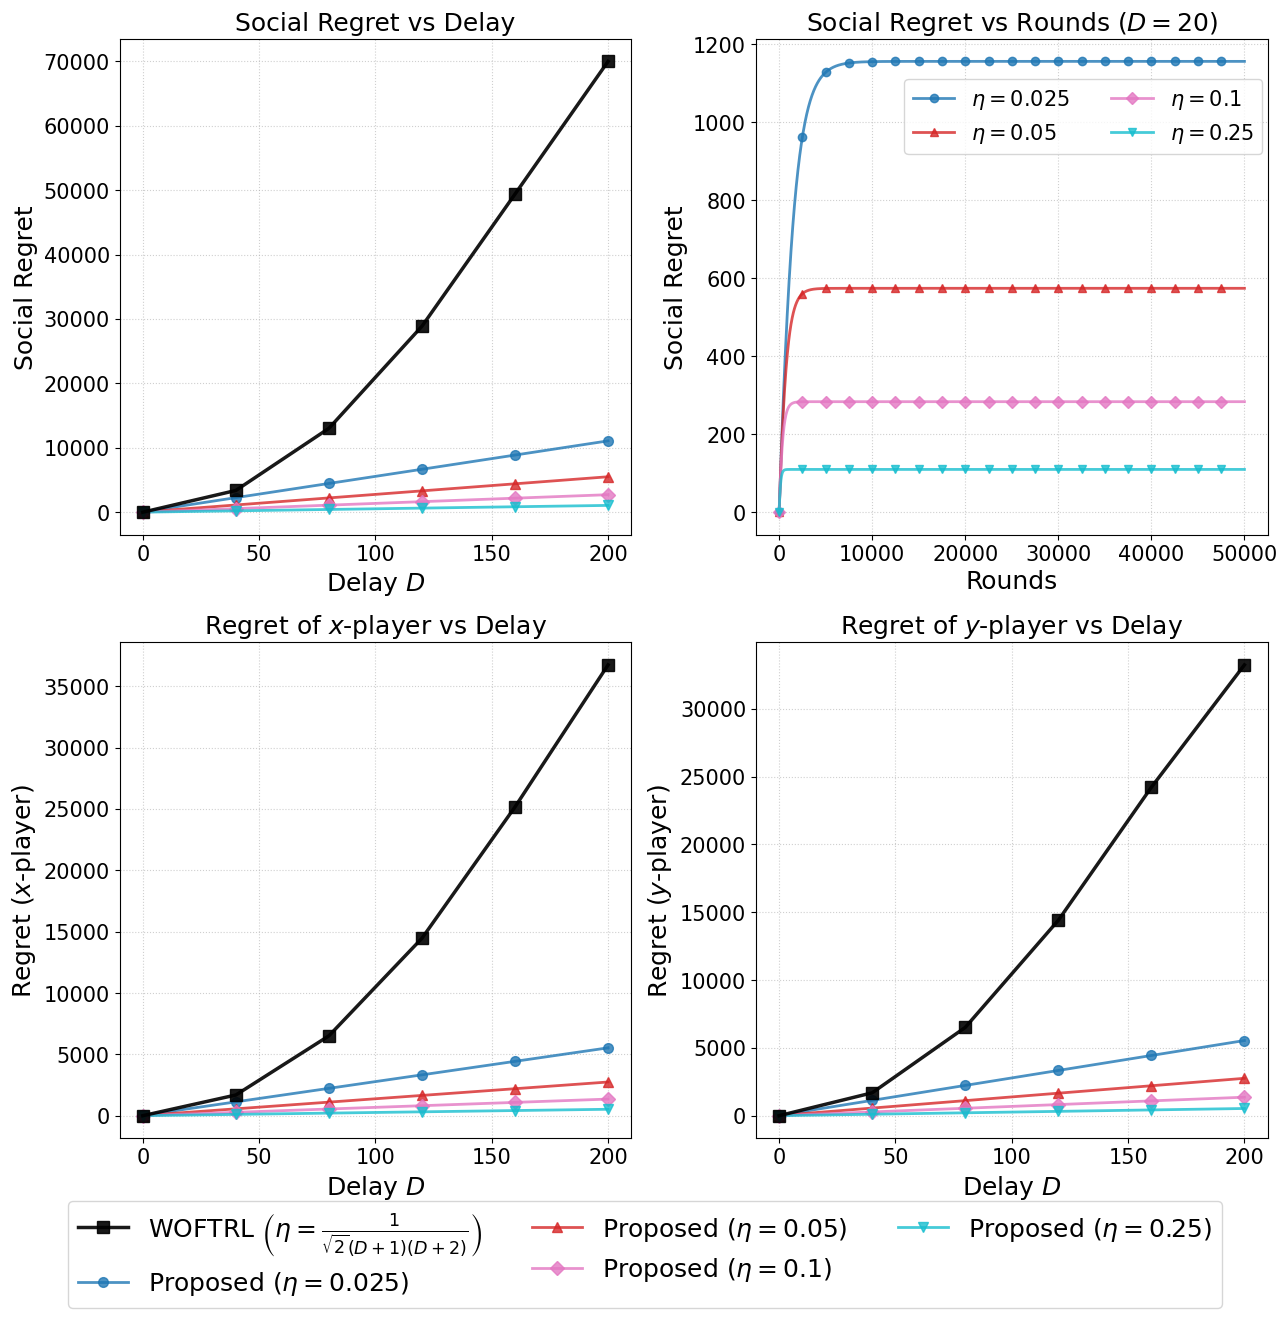

In [10]:
seed1_normalized_key = "Normalized Random Matrix (seed=1)"
seed1_time_series_key = "Matrix_seed1"
seed1_normalized_data = results_normalized[seed1_normalized_key]
seed1_time_series_data = results_time_series[seed1_time_series_key]
seed1_time_series_D = D_VALUES_ANALYSIS[-1]

eta_cmap_individual = plt.cm.get_cmap("tab10", len(PROPOSED_ETA_VALUES_normalized))
eta_colors_individual = {
    eta: eta_cmap_individual(i) for i, eta in enumerate(PROPOSED_ETA_VALUES_normalized)
}
proposed_markers_individual = {
    eta: marker
    for eta, marker in zip(PROPOSED_ETA_VALUES_normalized, ["o", "^", "D", "v"])
}

eta_cmap_ts = plt.cm.get_cmap("tab10", len(ETA_VALUES_ANALYSIS))
eta_colors_ts = {eta: eta_cmap_ts(i) for i, eta in enumerate(ETA_VALUES_ANALYSIS)}
eta_markers_ts = {
    eta: marker for eta, marker in zip(ETA_VALUES_ANALYSIS, ["o", "^", "D", "v"])
}
markevery_ts = max(T_analysis // 20, 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 13))

ax = axes[0, 0]
fujimoto_social_regret = np.array(seed1_normalized_data["Fujimoto"]["regret_x"]) + np.array(
    seed1_normalized_data["Fujimoto"]["regret_y"]
)
ax.plot(
    D_VALUES_normalized,
    fujimoto_social_regret,
    "s-",
    linewidth=2.5,
    markersize=8,
    label=r"WOFTRL $\left(\eta = \frac{1}{\sqrt{2} (D+1)(D+2)}\right)$",
    color="black",
    alpha=0.9,
    zorder=10,
)
for eta in PROPOSED_ETA_VALUES_normalized:
    marker = proposed_markers_individual[eta]
    ax.plot(
        D_VALUES_normalized,
        np.array(seed1_normalized_data["Proposed"][eta]["regret_x"])
        + np.array(seed1_normalized_data["Proposed"][eta]["regret_y"]),
        "-",
        linewidth=2,
        marker=marker,
        markersize=7,
        label=f"Proposed ($\\eta={eta}$)",
        color=eta_colors_individual[eta],
        alpha=0.8,
    )
ax.set_xlabel("Delay $D$", fontsize=18)
ax.set_ylabel("Social Regret", fontsize=18)
ax.set_title("Social Regret vs Delay", fontsize=18)
ax.tick_params(axis="both", which="major", labelsize=15)
ax.grid(True, linestyle=":", alpha=0.6)

ax = axes[0, 1]
time_steps = np.arange(1, T_analysis + 1)
for eta in ETA_VALUES_ANALYSIS:
    regret_x_history = seed1_time_series_data["D_eta_results"][seed1_time_series_D][eta]["regret_x"]
    regret_y_history = seed1_time_series_data["D_eta_results"][seed1_time_series_D][eta]["regret_y"]
    ax.plot(
        time_steps,
        regret_x_history + regret_y_history,
        linewidth=2,
        marker=eta_markers_ts[eta],
        markevery=markevery_ts,
        markersize=6,
        label=f"$\\eta={eta}$",
        color=eta_colors_ts[eta],
        alpha=0.8,
    )
ax.set_xlabel("Rounds", fontsize=18)
ax.set_ylabel("Social Regret", fontsize=18)
ax.set_title(f"Social Regret vs Rounds ($D={seed1_time_series_D}$)", fontsize=18)
ax.tick_params(axis="both", which="major", labelsize=15)
ax.grid(True, linestyle=":", alpha=0.6)

ax = axes[1, 0]
fujimoto_regret_x = np.array(seed1_normalized_data["Fujimoto"]["regret_x"])
ax.plot(
    D_VALUES_normalized,
    fujimoto_regret_x,
    "s-",
    linewidth=2.5,
    markersize=8,
    label=r"WOFTRL $\left(\eta = \frac{1}{\sqrt{2} (D+1)(D+2)}\right)$",
    color="black",
    alpha=0.9,
    zorder=10,
)
for eta in PROPOSED_ETA_VALUES_normalized:
    marker = proposed_markers_individual[eta]
    ax.plot(
        D_VALUES_normalized,
        np.array(seed1_normalized_data["Proposed"][eta]["regret_x"]),
        "-",
        linewidth=2,
        marker=marker,
        markersize=7,
        label=f"Proposed ($\\eta={eta}$)",
        color=eta_colors_individual[eta],
        alpha=0.8,
    )
ax.set_xlabel("Delay $D$", fontsize=18)
ax.set_ylabel("Regret ($x$-player)", fontsize=18)
ax.set_title("Regret of $x$-player vs Delay", fontsize=18)
ax.tick_params(axis="both", which="major", labelsize=15)
ax.grid(True, linestyle=":", alpha=0.6)

ax = axes[1, 1]
fujimoto_regret_y = np.array(seed1_normalized_data["Fujimoto"]["regret_y"])
ax.plot(
    D_VALUES_normalized,
    fujimoto_regret_y,
    "s-",
    linewidth=2.5,
    markersize=8,
    label=r"WOFTRL $\left(\eta = \frac{1}{\sqrt{2} (D+1)(D+2)}\right)$",
    color="black",
    alpha=0.9,
    zorder=10,
)
for eta in PROPOSED_ETA_VALUES_normalized:
    marker = proposed_markers_individual[eta]
    ax.plot(
        D_VALUES_normalized,
        np.array(seed1_normalized_data["Proposed"][eta]["regret_y"]),
        "-",
        linewidth=2,
        marker=marker,
        markersize=7,
        label=f"Proposed ($\\eta={eta}$)",
        color=eta_colors_individual[eta],
        alpha=0.8,
    )
ax.set_xlabel("Delay $D$", fontsize=18)
ax.set_ylabel("Regret ($y$-player)", fontsize=18)
ax.set_title("Regret of $y$-player vs Delay", fontsize=18)
ax.tick_params(axis="both", which="major", labelsize=15)
ax.grid(True, linestyle=":", alpha=0.6)

handles_delay, labels_delay = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles_delay,
    labels_delay,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    fontsize=18,
    frameon=True,
)
axes[0, 1].legend(loc="upper right", bbox_to_anchor=(1.01, 0.94), fontsize=15, ncol=2, frameon=True)

plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()